# 전기차 에너지 소비 데이터 분석

이 노트북은 `datas/ev_energy_consumption.csv`를 이용해 전기차 에너지 소비량의 분포와 영향 요인을 분석하고 회귀 모델을 학습합니다.

- Target: `energy_consumption_kwhper100km`
- 모델: Linear Regression, Random Forest, Gradient Boosting, SVR 비교
- 평가 지표: R², MAE, RMSE
- 최종 결과: 성능이 가장 좋은 모델, 변수 중요도, 테스트 데이터 예측 결과

에너지 소비량은 연속적인 숫자이므로 이 프로젝트는 **회귀 문제**입니다. 따라서 예측 오차와 설명력을 나타내는 `R²`, `MAE`, `RMSE`를 사용합니다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42
DATA_PATH = Path('datas/ev_energy_consumption.csv')
TARGET = 'energy_consumption_kwhper100km'
BASE_FEATURES = [
    'speed_kmh', 'payload_kg', 'ambient_temp_C', 'hvac_power_kw',
    'road_grade_pct', 'battery_temp_C', 'driving_style_index',
    'tire_pressure_bar', 'trip_distance_km'
]

# 기준값은 데이터의 물리적 해석을 위한 실험용 기준이다.
COMFORTABLE_AMBIENT_TEMP_C = 25.0
OPTIMAL_BATTERY_TEMP_C = 30.0
OPTIMAL_TIRE_PRESSURE_BAR = 2.4

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'{DATA_PATH} 파일이 없습니다. CSV를 datas 폴더에 저장한 뒤 다시 실행하세요.'
    )

df = pd.read_csv(DATA_PATH)
required_columns = set(BASE_FEATURES + [TARGET])
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'필수 컬럼이 없습니다: {sorted(missing_columns)}')

# 원본 CSV는 보존하고 분석용 복사본에서만 결측치 처리를 수행한다.
df = df[BASE_FEATURES + [TARGET]].copy()
missing_before = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())
df = df.dropna().reset_index(drop=True)

print(f'원본 행/열: {df.shape[0]:,}행 x {df.shape[1]}열')
print(f'제거한 결측값: {missing_before:,}개 | 중복 행: {duplicate_rows:,}개')
display(df.head())
display(df.describe().T)
display(df.isna().sum().rename('missing').to_frame())


def create_ev_features(data):
    """전기차 소비량에 의미가 있는 비선형 및 상호작용 변수를 생성한다."""
    engineered = data.copy()
    engineered['speed_squared'] = engineered['speed_kmh'] ** 2
    engineered['ambient_temp_deviation'] = (
        engineered['ambient_temp_C'] - COMFORTABLE_AMBIENT_TEMP_C
    ).abs()
    engineered['battery_temp_deviation'] = (
        engineered['battery_temp_C'] - OPTIMAL_BATTERY_TEMP_C
    ).abs()
    engineered['tire_pressure_deviation'] = (
        engineered['tire_pressure_bar'] - OPTIMAL_TIRE_PRESSURE_BAR
    ).abs()
    engineered['payload_grade'] = (
        engineered['payload_kg'] * engineered['road_grade_pct']
    )
    engineered['hvac_temp_interaction'] = (
        engineered['hvac_power_kw'] * engineered['ambient_temp_deviation']
    )
    engineered['speed_driving_interaction'] = (
        engineered['speed_kmh'] * engineered['driving_style_index']
    )
    return engineered


df_engineered = create_ev_features(df)
engineered_features = [column for column in df_engineered.columns if column != TARGET]
print(f'기본 피처: {len(BASE_FEATURES)}개 -> 파생변수 포함: {len(engineered_features)}개')
display(df_engineered.head())

원본 행/열: 8,000행 x 10열
제거한 결측값: 0개 | 중복 행: 0개


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


,count,mean,std,min,25%,50%,75%,max
speed_kmh,8000.0,74.427013,31.789245,20.00,46.775,74.2000,101.800,130.0
payload_kg,8000.0,248.822563,144.327869,0.00,124.300,246.8500,376.125,500.0
ambient_temp_C,8000.0,15.587013,14.396150,-10.00,3.475,15.8000,27.900,40.0
hvac_power_kw,8000.0,2.477026,1.435208,0.00,1.230,2.4800,3.700,5.0
road_grade_pct,8000.0,1.464087,3.744704,-5.00,-1.790,1.5000,4.670,8.0
battery_temp_C,8000.0,29.970725,8.717058,15.00,22.300,29.9000,37.700,45.0
driving_style_index,8000.0,0.499641,0.286885,0.00,0.254,0.5020,0.745,1.0
tire_pressure_bar,8000.0,2.401016,0.230790,2.00,2.200,2.4000,2.600,2.8
trip_distance_km,8000.0,102.692337,55.844911,5.10,54.300,103.2500,151.700,200.0
energy_consumption_kwhper100km,8000.0,24.137613,3.738082,11.62,21.514,24.0925,26.753,35.0


,missing
speed_kmh,0
payload_kg,0
ambient_temp_C,0
hvac_power_kw,0
road_grade_pct,0
battery_temp_C,0
driving_style_index,0
tire_pressure_bar,0
trip_distance_km,0
energy_consumption_kwhper100km,0


기본 피처: 9개 -> 파생변수 포함: 16개


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km,speed_squared,ambient_temp_deviation,battery_temp_deviation,tire_pressure_deviation,payload_grade,hvac_temp_interaction,speed_driving_interaction
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357,3745.44,34.8,6.0,0.02,-1674.465,119.364,42.0444
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554,15525.16,35.0,12.2,0.39,-1683.640,81.900,51.4598
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004,10100.25,11.4,11.2,0.18,-99.632,3.192,28.1400
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539,7378.81,33.5,9.6,0.28,2486.407,153.765,52.9144
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883,1383.84,13.7,8.9,0.05,1921.192,67.130,27.5280


## 1. 데이터 탐색과 전처리

에너지 소비량은 연속적인 숫자이므로 이 프로젝트는 **회귀 문제**입니다. 예측 오차와 설명력을 나타내는 `R²`, `MAE`, `RMSE`를 사용합니다.

단순한 원본 피처만으로는 속도에 따른 공기저항, 온도 편차, 적재량과 경사도의 결합 효과를 충분히 표현하기 어렵습니다. 그래서 원본 데이터는 유지한 채 다음 물리적 가정을 반영한 파생변수를 추가합니다.

- `speed_squared`: 속도가 증가할수록 커지는 공기저항 효과를 근사합니다.
- `ambient_temp_deviation`, `battery_temp_deviation`: 효율이 좋은 기준 온도에서 벗어난 정도입니다.
- `tire_pressure_deviation`: 기준 공기압에서 벗어난 정도입니다.
- `payload_grade`: 적재량과 경사도의 결합 효과입니다.
- `hvac_temp_interaction`: HVAC 사용량과 외기온도 편차의 결합 효과입니다.
- `speed_driving_interaction`: 속도와 운전 성향의 결합 효과입니다.

,correlation_with_target
ambient_temp_C,-0.155499
tire_pressure_bar,-0.095066
battery_temp_C,-0.086873
battery_temp_deviation,-0.013635
tire_pressure_deviation,0.001177
trip_distance_km,0.171982
ambient_temp_deviation,0.198043
driving_style_index,0.258434
hvac_temp_interaction,0.351334
hvac_power_kw,0.369619


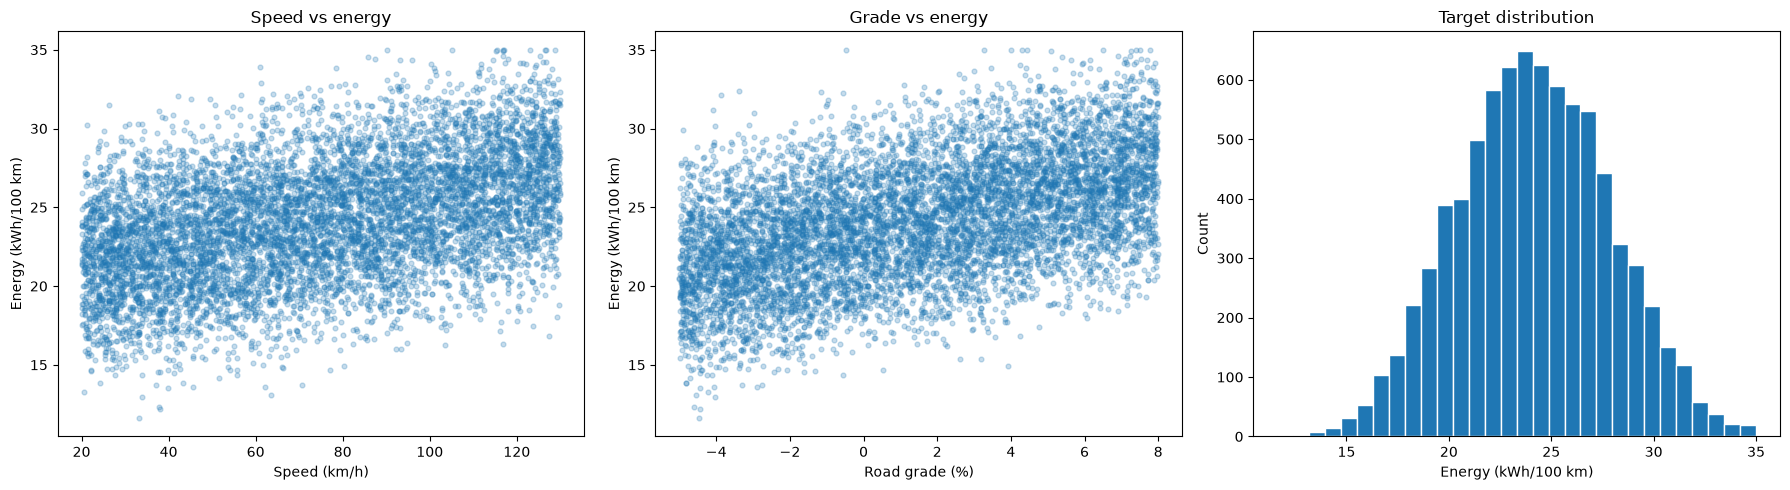

In [3]:
correlation = df_engineered[engineered_features + [TARGET]].corr(numeric_only=True)[TARGET].sort_values()
display(correlation.to_frame('correlation_with_target'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(df['speed_kmh'], df[TARGET], alpha=0.25, s=12)
axes[0].set(xlabel='Speed (km/h)', ylabel='Energy (kWh/100 km)', title='Speed vs energy')
axes[1].scatter(df['road_grade_pct'], df[TARGET], alpha=0.25, s=12)
axes[1].set(xlabel='Road grade (%)', ylabel='Energy (kWh/100 km)', title='Grade vs energy')
axes[2].hist(df[TARGET], bins=30, edgecolor='white')
axes[2].set(xlabel='Energy (kWh/100 km)', ylabel='Count', title='Target distribution')
plt.tight_layout()
plt.show()

In [4]:
# 동일한 분할을 모든 실험에 사용해 전처리 방법의 차이만 비교한다.
X_base = df[BASE_FEATURES]
X_engineered = df_engineered[engineered_features]
y = df[TARGET]
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE
)
X_engineered_train = X_engineered.loc[X_base_train.index]
X_engineered_test = X_engineered.loc[X_base_test.index]

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'SVR': SVR(C=10, epsilon=0.1, kernel='rbf'),
}

# 네 실험은 같은 모델군을 사용하되 입력 피처와 스케일링 여부만 바꾼다.
experiments = {
    'A. Baseline': (X_base_train, X_base_test, False),
    'B. Baseline + Scaling': (X_base_train, X_base_test, True),
    'C. Feature Engineering': (X_engineered_train, X_engineered_test, False),
    'D. Feature Engineering + Scaling': (X_engineered_train, X_engineered_test, True),
}

results = []
trained_models = {}
for experiment_name, (train_features, test_features, use_scaling) in experiments.items():
    for model_name, estimator in models.items():
        # 스케일러는 train에만 fit되고 test에는 transform만 적용되어 누수를 막는다.
        model = make_pipeline(StandardScaler(), estimator) if use_scaling else estimator
        model.fit(train_features, y_train)
        predictions = model.predict(test_features)
        results.append({
            'experiment': experiment_name,
            'model': model_name,
            'R2': r2_score(y_test, predictions),
            'MAE_kWh_per_100km': mean_absolute_error(y_test, predictions),
            'RMSE_kWh_per_100km': np.sqrt(mean_squared_error(y_test, predictions)),
        })
        trained_models[(experiment_name, model_name)] = model

results_df = pd.DataFrame(results).sort_values('RMSE_kWh_per_100km')
display(results_df)
best_result = results_df.iloc[0]
best_experiment = best_result['experiment']
best_model_name = best_result['model']
best_model = trained_models[(best_experiment, best_model_name)]
print(
    f"선정 모델: {best_experiment} / {best_model_name} "
    f"(RMSE={best_result['RMSE_kWh_per_100km']:.3f})"
)

,experiment,model,R2,MAE_kWh_per_100km,RMSE_kWh_per_100km
12,D. Feature Engineering + Scaling,Linear Regression,0.941720,0.704513,0.887474
8,C. Feature Engineering,Linear Regression,0.941720,0.704513,0.887474
7,B. Baseline + Scaling,SVR,0.939416,0.723187,0.904847
15,D. Feature Engineering + Scaling,SVR,0.937561,0.735062,0.918596
6,B. Baseline + Scaling,Gradient Boosting,0.934634,0.750800,0.939878
2,A. Baseline,Gradient Boosting,0.934599,0.750975,0.940131
14,D. Feature Engineering + Scaling,Gradient Boosting,0.930056,0.766250,0.972235
10,C. Feature Engineering,Gradient Boosting,0.930052,0.766316,0.972267
0,A. Baseline,Linear Regression,0.924621,0.810735,1.009304
4,B. Baseline + Scaling,Linear Regression,0.924621,0.810735,1.009304


선정 모델: D. Feature Engineering + Scaling / Linear Regression (RMSE=0.887)


## 3. 모델 성능 비교와 전처리 최적화

네 가지 실험을 **동일한 Train/Test 데이터**에서 수행합니다.

1. `A. Baseline`: 원본 9개 피처
2. `B. Baseline + Scaling`: 원본 피처 + `StandardScaler`
3. `C. Feature Engineering`: 원본 피처 + 물리 기반 파생변수 7개
4. `D. Feature Engineering + Scaling`: 파생변수 16개 + `StandardScaler`

`StandardScaler`는 각 실험의 학습 데이터에만 `fit`하고 테스트 데이터에는 `transform`만 적용합니다. 이렇게 해야 테스트 데이터의 평균과 표준편차가 학습에 미리 노출되는 데이터 누수를 막을 수 있습니다.

스케일링은 선형회귀와 SVR처럼 변수 크기에 영향을 받는 모델에 특히 중요합니다. Random Forest와 Gradient Boosting은 분기 기준을 사용하므로 스케일링의 효과가 상대적으로 작습니다.

성능이 가장 좋은 모델은 `RMSE`가 가장 낮은 행으로 선택합니다. `RMSE`는 큰 예측 오차에 더 큰 패널티를 주므로 소비전력 예측에서 위험한 큰 오차를 줄이는 데 적합합니다.

,absolute_standardized_coefficient
road_grade_pct,1.869396
payload_kg,1.736377
speed_kmh,1.359588
hvac_power_kw,1.289825
driving_style_index,1.008273
ambient_temp_deviation,0.866273
trip_distance_km,0.571694
tire_pressure_bar,0.331360
speed_squared,0.291040
battery_temp_C,0.255789


,actual_energy_kwhper100km,predicted_energy_kwhper100km
17,23.804,23.470433
19,19.439,19.138542
23,22.948,23.607079
26,23.405,22.394800
31,23.959,24.154176
33,24.103,24.000826
37,22.053,21.968420
41,21.447,21.004306
48,28.394,28.716287
50,23.962,23.990133


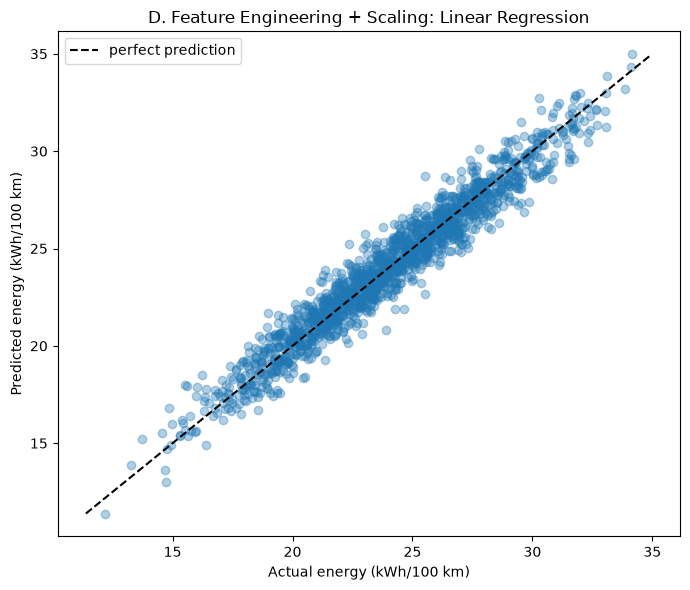

In [5]:
# 최종 모델에 맞는 피처 중요도 계산
if best_model_name == 'Linear Regression':
    final_estimator = best_model[-1] if hasattr(best_model, '__getitem__') else best_model
    importance_values = np.abs(final_estimator.coef_)
    importance_label = 'absolute_standardized_coefficient'
elif best_model_name == 'SVR':
    raise ValueError('SVR은 기본적으로 해석 가능한 피처 중요도를 제공하지 않습니다.')
else:
    final_estimator = best_model[-1] if hasattr(best_model, '__getitem__') else best_model
    importance_values = final_estimator.feature_importances_
    importance_label = 'feature_importance'

importance_features = engineered_features if best_experiment.startswith(('C.', 'D.')) else BASE_FEATURES
feature_importance = pd.Series(
    importance_values, index=importance_features
).sort_values(ascending=False)
display(feature_importance.to_frame(importance_label))

best_test_features = (
    X_engineered_test if best_experiment.startswith(('C.', 'D.')) else X_base_test
)
test_predictions = best_model.predict(best_test_features)
prediction_df = pd.DataFrame({
    'actual_energy_kwhper100km': y_test,
    'predicted_energy_kwhper100km': test_predictions,
}).sort_index()
display(prediction_df.head(10))

plt.figure(figsize=(7, 6))
plt.scatter(
    prediction_df['actual_energy_kwhper100km'],
    prediction_df['predicted_energy_kwhper100km'],
    alpha=0.35,
)
axis_limits = [prediction_df.min().min(), prediction_df.max().max()]
plt.plot(axis_limits, axis_limits, '--', color='black', label='perfect prediction')
plt.xlabel('Actual energy (kWh/100 km)')
plt.ylabel('Predicted energy (kWh/100 km)')
plt.title(f'{best_experiment}: {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
baseline_rmse = results_df.loc[
    results_df['experiment'].eq('A. Baseline'), 'RMSE_kWh_per_100km'
].min()
best_rmse = float(best_result['RMSE_kWh_per_100km'])
rmse_improvement_pct = (baseline_rmse - best_rmse) / baseline_rmse * 100

residuals = prediction_df['actual_energy_kwhper100km'] - prediction_df['predicted_energy_kwhper100km']
summary = pd.Series({
    '선정 실험': best_experiment,
    '선정 모델': best_model_name,
    '테스트 샘플 수': len(prediction_df),
    'R²': best_result['R2'],
    '평균 절대 오차 (kWh/100km)': mean_absolute_error(y_test, test_predictions),
    'RMSE (kWh/100km)': best_rmse,
    'Baseline 대비 RMSE 개선율 (%)': rmse_improvement_pct,
    '평균 잔차 (kWh/100km)': residuals.mean(),
    '최대 절대 잔차 (kWh/100km)': residuals.abs().max(),
})
display(summary.to_frame('value').round(4))

print(
    f'결론: 파생변수와 스케일링을 적용한 {best_model_name}이 '
    f'Baseline보다 RMSE를 {rmse_improvement_pct:.2f}% 개선했습니다.'
)

,value
선정 실험,D. Feature Engineering + Scaling
선정 모델,Linear Regression
테스트 샘플 수,1600
R²,0.94172
평균 절대 오차 (kWh/100km),0.704513
RMSE (kWh/100km),0.887474
Baseline 대비 RMSE 개선율 (%),5.600993
평균 잔차 (kWh/100km),-0.017901
최대 절대 잔차 (kWh/100km),3.200037


결론: 파생변수와 스케일링을 적용한 Linear Regression이 Baseline보다 RMSE를 5.60% 개선했습니다.


## 4. 물류 운행 서비스 구현

머신러닝 분석 결과를 실제 서비스 흐름에 연결하기 위한 첫 단계입니다. 이 부분부터는 사용자의 8자리 사원번호와 날짜를 이용해 차량, 화물, 날씨, HVAC 조건을 결정적으로 생성합니다.

서비스 구현 순서:

1. 공통 설정과 라이브러리 준비
2. 사원번호와 날짜 입력 검증
3. 차량 CSV 로드 및 차량 선택
4. 날씨와 HVAC 조건 생성
5. 최종 일일 배차 결과 생성

같은 사원번호와 날짜를 다시 입력하면 같은 배차가 생성되도록 SHA-256 기반 seed를 사용합니다. 따라서 데모나 테스트에서 결과를 재현할 수 있습니다.

In [7]:
import csv
import hashlib
import random
from datetime import date, datetime
from pathlib import Path
from typing import Any


# 노트북은 프로젝트 루트에서 실행된다고 가정하고 서비스 데이터 위치를 정의한다.
PROJECT_ROOT = Path.cwd()
DEFAULT_VEHICLE_DATA_PATH = (
    PROJECT_ROOT / 'datas' / 'vehicles_volvo_fh_electric_10.csv'
)
VALID_WEATHER_TYPES = ('cold', 'normal', 'hot')

print(f'차량 데이터 경로: {DEFAULT_VEHICLE_DATA_PATH}')
print(f'차량 데이터 존재 여부: {DEFAULT_VEHICLE_DATA_PATH.exists()}')

차량 데이터 경로: /home/aiuser/E_car/datas/vehicles_volvo_fh_electric_10.csv
차량 데이터 존재 여부: True


### 4-1. 사원번호와 날짜 검증

사원번호는 서비스 접근의 기본 입력값이므로 숫자 8자리인지 먼저 확인합니다. 날짜는 배차 결과를 재현하기 위한 두 번째 seed 요소입니다. 입력을 표준 형식으로 바꾸면 `2026-08-28`과 같은 날짜 표현이 항상 동일하게 처리됩니다.

In [8]:
def validate_employee_id(employee_id: str) -> str:
    """서비스에서 사용할 수 있는 8자리 숫자 사원번호만 허용한다."""
    normalized_id = str(employee_id).strip()
    if not (normalized_id.isdigit() and len(normalized_id) == 8):
        raise ValueError('사원번호는 숫자 8자리여야 합니다.')
    return normalized_id


def normalize_assignment_date(
    assignment_date: date | datetime | str | None,
) -> str:
    """날짜 입력을 seed에 사용할 YYYY-MM-DD 문자열로 통일한다."""
    if assignment_date is None:
        return date.today().isoformat()
    if isinstance(assignment_date, datetime):
        return assignment_date.date().isoformat()
    if isinstance(assignment_date, date):
        return assignment_date.isoformat()
    try:
        return date.fromisoformat(str(assignment_date).strip()).isoformat()
    except ValueError as error:
        raise ValueError('배차 날짜는 YYYY-MM-DD 형식이어야 합니다.') from error


def make_assignment_seed(employee_id: str, assignment_date: str) -> int:
    """실행 환경이 달라도 같은 입력에 같은 seed가 나오도록 한다."""
    seed_source = f'{employee_id}:{assignment_date}'.encode('utf-8')
    digest = hashlib.sha256(seed_source).digest()
    return int.from_bytes(digest[:8], byteorder='big')


validated_id = validate_employee_id('12345678')
validated_date = normalize_assignment_date('2026-08-28')
print(f'검증된 사원번호: {validated_id}')
print(f'표준화된 배차일: {validated_date}')
print(f'생성된 seed: {make_assignment_seed(validated_id, validated_date)}')

검증된 사원번호: 12345678
표준화된 배차일: 2026-08-28
생성된 seed: 3560382759065967694


### 4-2. 차량 CSV 로드와 기본 차량 배정

차량별 배터리 용량, 충전 출력, 최대 적재량, 타이어 공기압은 `vehicles_volvo_fh_electric_10.csv`에서 읽습니다. 데이터 파일의 필수 컬럼을 먼저 검증해 이후 서비스 단계에서 누락된 값으로 계산하지 않도록 합니다.

In [9]:
def load_vehicles(
    vehicle_data_path: str | Path = DEFAULT_VEHICLE_DATA_PATH,
) -> list[dict[str, Any]]:
    """차량 CSV를 읽고 배차에 필요한 컬럼이 있는지 검사한다."""
    path = Path(vehicle_data_path)
    if not path.exists():
        raise FileNotFoundError(f'차량 데이터 파일을 찾을 수 없습니다: {path}')

    with path.open(newline='', encoding='utf-8-sig') as file:
        vehicles = list(csv.DictReader(file))

    required_columns = {
        'vehicle_id',
        'display_name',
        'project_max_payload_kg',
        'tire_pressure_bar',
    }
    actual_columns = set(vehicles[0]) if vehicles else set()
    if not vehicles or not required_columns.issubset(actual_columns):
        missing = sorted(required_columns.difference(actual_columns))
        raise ValueError(f'차량 CSV에 필요한 컬럼이 없습니다: {missing}')
    return vehicles


vehicles = load_vehicles()
print(f'사용 가능한 차량 수: {len(vehicles)}대')
print(f'차량 목록: {[vehicle["display_name"] for vehicle in vehicles]}')

사용 가능한 차량 수: 10대
차량 목록: ['Volvo FH Electric 01호차', 'Volvo FH Electric 02호차', 'Volvo FH Electric 03호차', 'Volvo FH Electric 04호차', 'Volvo FH Electric 05호차', 'Volvo FH Electric 06호차', 'Volvo FH Electric 07호차', 'Volvo FH Electric 08호차', 'Volvo FH Electric 09호차', 'Volvo FH Electric 10호차']


### 4-3. 운행환경과 HVAC 생성

날씨는 단순한 화면 표시값이 아니라 머신러닝 입력값으로 사용될 환경 데이터입니다. 따라서 날씨 유형과 외기온도, HVAC 모드, HVAC 전력을 하나의 함수에서 함께 생성해 서로 모순되지 않게 관리합니다.

In [10]:
def create_weather(rng: random.Random) -> dict[str, Any]:
    """날씨 유형에 맞는 외기온도와 HVAC 상태를 생성한다."""
    weather_type = rng.choice(VALID_WEATHER_TYPES)
    if weather_type == 'cold':
        return {
            'weather_type': weather_type,
            'ambient_temp_C': round(rng.uniform(-10.0, 5.0), 1),
            'hvac_mode': 'HEATING',
            'hvac_power_kw': round(rng.uniform(2.0, 5.0), 2),
        }
    if weather_type == 'hot':
        return {
            'weather_type': weather_type,
            'ambient_temp_C': round(rng.uniform(30.0, 40.0), 1),
            'hvac_mode': 'COOLING',
            'hvac_power_kw': round(rng.uniform(2.0, 5.0), 2),
        }
    return {
        'weather_type': weather_type,
        'ambient_temp_C': round(rng.uniform(15.0, 25.0), 1),
        'hvac_mode': 'OFF',
        'hvac_power_kw': 0.0,
    }


weather_examples = [create_weather(random.Random(seed)) for seed in range(3)]
display(pd.DataFrame(weather_examples))

,weather_type,ambient_temp_C,hvac_mode,hvac_power_kw
0,normal,22.6,OFF,0.00
1,cold,-1.5,HEATING,4.41
2,cold,-8.6,HEATING,3.08


### 4-4. 일일 배차 결과 생성

앞 단계에서 준비한 검증 함수, 차량 목록, 날씨 생성기를 하나로 연결합니다. 차량을 먼저 결정한 뒤 해당 차량의 `project_max_payload_kg`를 상한으로 화물량을 생성하므로 차량별 적재 한계를 넘지 않습니다. 결과는 이후 에너지 예측, SOC 계산, 충전 계획 단계에서 사용할 수 있는 딕셔너리 구조입니다.

In [11]:
def assign_daily_dispatch(
    employee_id: str,
    assignment_date: date | datetime | str | None = None,
    vehicle_data_path: str | Path = DEFAULT_VEHICLE_DATA_PATH,
) -> dict[str, Any]:
    """같은 사원번호와 날짜에 대해 항상 같은 일일 배차를 생성한다."""

    normalized_id = validate_employee_id(employee_id)
    normalized_date = normalize_assignment_date(assignment_date)

    seed = make_assignment_seed(normalized_id, normalized_date)
    rng = random.Random(seed)

    # 차량 랜덤 선택
    vehicle = rng.choice(load_vehicles(vehicle_data_path))

    # 차량 최대 적재량
    max_payload_kg = float(vehicle['project_max_payload_kg'])

    # 날씨 생성
    weather = create_weather(rng)

        # --------------------------------
    # 화물량 생성
    # 1세트 = 10kg
    # 기본 화물량 = 3세트
    # --------------------------------

    payload_per_set_kg = 10
    payload_set_count = 3

    # 최종 화물 무게
    total_payload_kg = payload_set_count * payload_per_set_kg
    if total_payload_kg > max_payload_kg:
        raise ValueError(
            f'생성된 화물량({total_payload_kg:g}kg)이 차량 최대 적재량'
            f'({max_payload_kg:g}kg)을 초과합니다.'
        )




    return {
        'employee_id': normalized_id,
        'assignment_date': normalized_date,
        'seed': seed,

        'vehicle': {
            **vehicle,
            'battery_capacity_gross_kwh': float(
                vehicle['battery_capacity_gross_kwh']
            ),
            'battery_usable_kwh': float(
                vehicle['battery_usable_kwh']
            ),
            'max_dc_charge_kw': float(
                vehicle['max_dc_charge_kw']
            ),
            'project_max_payload_kg': max_payload_kg,
            'tire_pressure_bar': float(
                vehicle['tire_pressure_bar']
            ),
            'default_soc_pct': float(
                vehicle['default_soc_pct']
            ),
        },

        # 화물 정보
        'payload_set_count': payload_set_count,
        'payload_per_set_kg': payload_per_set_kg,
        'payload_kg': total_payload_kg,

        'weather': weather,
    }



# =====================================
# 충전 규칙
# 충전하면 무조건 100%까지 충전
# =====================================

def charge_to_full(
    current_soc_pct: float,
    battery_usable_kwh: float
) -> dict:

    current_soc_pct = max(0.0, min(100.0, float(current_soc_pct)))

    target_soc_pct = 100.0

    charged_energy_kwh = (
        battery_usable_kwh
        * (target_soc_pct - current_soc_pct)
        / 100
    )

    return {
        'soc_before_pct': current_soc_pct,
        'soc_after_pct': 100.0,
        'charged_energy_kwh': charged_energy_kwh,
    }


# =====================================
# 테스트
# =====================================

assignment = assign_daily_dispatch(
    '12345678',
    '2026-08-28'
)

# =====================================
# 결과 출력
# =====================================

assignment_result = pd.Series({
    '사원번호': assignment['employee_id'],
    '배차일': assignment['assignment_date'],

    '차량': assignment['vehicle']['display_name'],

    '화물 세트 수': assignment['payload_set_count'],
    '세트당 무게(kg)': assignment['payload_per_set_kg'],
    '총 화물량(kg)': assignment['payload_kg'],

    '차량 최대 적재량(kg)':
        assignment['vehicle']['project_max_payload_kg'],

    '날씨': assignment['weather']['weather_type'],
    'HVAC': assignment['weather']['hvac_mode'],
    '외기온도(C)': assignment['weather']['ambient_temp_C'],
    'HVAC 전력(kW)': assignment['weather']['hvac_power_kw'],
})


display(
    assignment_result.to_frame('배차 결과')
)

,배차 결과
사원번호,12345678
배차일,2026-08-28
차량,Volvo FH Electric 10호차
화물 세트 수,3
세트당 무게(kg),10
총 화물량(kg),30
차량 최대 적재량(kg),23500.0
날씨,normal
HVAC,OFF
외기온도(C),24.9


## 5. 일일 차량 배정 저장 및 중복 처리

배차 결과를 `datas/daily_vehicle_assignments.csv`에 누적 저장합니다. 저장 파일에는 사원번호, 배차일, 차량, 화물량, 날씨, HVAC 등 이후 서비스에서 필요한 값을 한 행으로 기록합니다.

처리 순서:

1. 입력한 사원번호와 날짜로 오늘의 배차 후보를 생성합니다.
2. 해당 날짜에 이미 사용 중인 차량을 CSV에서 조회합니다.
3. 비어 있는 차량이 있으면 그 차량을 배정합니다.
4. 모든 차량이 사용 중이면 `이미 배정된 차량입니다` 알림을 출력합니다.
5. 확인(`overwrite_confirmed=True`)이면 선택한 기존 차량의 저장 행을 삭제하고 새 배차로 덮어씁니다.
6. 취소(`overwrite_confirmed=False`)이면 기존 차량 배정은 보존하고 `예비차량`으로 새 행을 저장합니다.

같은 사원번호가 같은 날짜에 다시 입력된 경우에는 기존 사원 행을 갱신해 중복 행을 만들지 않습니다. 실제 버튼 UI에서는 확인 버튼이 `True`, 취소 버튼이 `False`를 전달하면 됩니다.

In [12]:
DAILY_ASSIGNMENT_PATH = PROJECT_ROOT / 'datas' / 'daily_vehicle_assignments.csv'
ASSIGNMENT_COLUMNS = [
    'assignment_date',
    'employee_id',
    'assignment_status',
    'vehicle_id',
    'vehicle_display_name',
    'payload_kg',
    'project_max_payload_kg',
    'tire_pressure_bar',
    'battery_usable_kwh',
    'max_dc_charge_kw',
    'default_soc_pct',
    'weather_type',
    'ambient_temp_C',
    'hvac_mode',
    'hvac_power_kw',
]


def load_daily_assignments(
    assignment_path: str | Path = DAILY_ASSIGNMENT_PATH,
) -> pd.DataFrame:
    """저장 파일이 없으면 같은 컬럼의 빈 DataFrame을 반환한다."""
    path = Path(assignment_path)
    if not path.exists():
        return pd.DataFrame(columns=ASSIGNMENT_COLUMNS)
    saved = pd.read_csv(
        path,
        dtype={'assignment_date': str, 'employee_id': str, 'vehicle_id': str},
    )
    missing = set(ASSIGNMENT_COLUMNS).difference(saved.columns)
    if missing:
        raise ValueError(f'배정 저장 CSV에 필요한 컬럼이 없습니다: {sorted(missing)}')
    return saved[ASSIGNMENT_COLUMNS].copy()


def assignment_to_row(
    assignment: dict[str, Any],
    assignment_status: str,
) -> dict[str, Any]:
    """배차 딕셔너리를 CSV 한 행에 저장할 평탄한 구조로 변환한다."""
    vehicle = assignment.get('vehicle') or {}
    weather = assignment['weather']
    return {
        'assignment_date': assignment['assignment_date'],
        'employee_id': assignment['employee_id'],
        'assignment_status': assignment_status,
        'vehicle_id': vehicle.get('vehicle_id', 'RESERVE_VEHICLE'),
        'vehicle_display_name': vehicle.get('display_name', '예비차량'),
        'payload_kg': assignment['payload_kg'],
        'project_max_payload_kg': vehicle.get('project_max_payload_kg', np.nan),
        'tire_pressure_bar': vehicle.get('tire_pressure_bar', np.nan),
        'battery_usable_kwh': vehicle.get('battery_usable_kwh', np.nan),
        'max_dc_charge_kw': vehicle.get('max_dc_charge_kw', np.nan),
        'default_soc_pct': vehicle.get('default_soc_pct', np.nan),
        'weather_type': weather['weather_type'],
        'ambient_temp_C': weather['ambient_temp_C'],
        'hvac_mode': weather['hvac_mode'],
        'hvac_power_kw': weather['hvac_power_kw'],
    }


def save_daily_dispatch(
    employee_id: str,
    assignment_date: date | datetime | str | None = None,
    overwrite_confirmed: bool = False,
    assignment_path: str | Path = DAILY_ASSIGNMENT_PATH,
    vehicle_data_path: str | Path = DEFAULT_VEHICLE_DATA_PATH,
) -> tuple[dict[str, Any], str]:
    """배차를 저장하고 실제 배정 상태와 저장 결과 메시지를 반환한다."""
    normalized_id = validate_employee_id(employee_id)
    normalized_date = normalize_assignment_date(assignment_date)
    saved = load_daily_assignments(assignment_path)

    # 같은 사원의 기존 당일 행은 갱신 대상으로 보고 먼저 제거한다.
    same_employee = (saved['assignment_date'] == normalized_date) & (
        saved['employee_id'] == normalized_id
    )
    saved = saved.loc[~same_employee].copy()

    vehicles = load_vehicles(vehicle_data_path)
    vehicle_ids = {vehicle['vehicle_id'] for vehicle in vehicles}
    used_vehicle_ids = set(
        saved.loc[
            (saved['assignment_date'] == normalized_date)
            & saved['vehicle_id'].isin(vehicle_ids),
            'vehicle_id',
        ]
    )
    available_vehicles = [
        vehicle for vehicle in vehicles if vehicle['vehicle_id'] not in used_vehicle_ids
    ]

    assignment = assign_daily_dispatch(
        normalized_id, normalized_date, vehicle_data_path=vehicle_data_path
    )
    rng = random.Random(assignment['seed'])

    if available_vehicles:
        # 기본 후보가 이미 사용 중이어도 빈 차량 중 하나를 결정적으로 선택한다.
        selected_vehicle = rng.choice(available_vehicles)
        assignment['vehicle'] = selected_vehicle
        status = 'ASSIGNED'
        message = f"차량 배정 완료: {selected_vehicle['display_name']}"
    else:
        print('알림: 모든 차량이 사용 중입니다. 이미 배정된 차량입니다.')
        if overwrite_confirmed:
            # 확인을 누른 경우 입력 seed로 교체할 기존 차량을 결정한다.
            target_vehicle = rng.choice(vehicles)
            saved = saved.loc[
                ~(
                    (saved['assignment_date'] == normalized_date)
                    & (saved['vehicle_id'] == target_vehicle['vehicle_id'])
                )
            ].copy()
            assignment['vehicle'] = target_vehicle
            status = 'OVERWRITTEN'
            message = f"기존 배정 삭제 후 덮어쓰기 완료: {target_vehicle['display_name']}"
        else:
            # 취소한 경우 실제 차량을 점유하지 않는 예비차량 행을 남긴다.
            assignment['vehicle'] = None
            status = 'RESERVE'
            message = '차량 배정 취소: 예비차량으로 저장했습니다.'

    new_row = pd.DataFrame([assignment_to_row(assignment, status)])
    updated = pd.concat([saved, new_row], ignore_index=True)[ASSIGNMENT_COLUMNS]
    Path(assignment_path).parent.mkdir(parents=True, exist_ok=True)
    updated.to_csv(assignment_path, index=False, encoding='utf-8-sig')
    return assignment, message


assignment, save_message = save_daily_dispatch('12345678', '2026-08-28')
print(save_message)
display(load_daily_assignments().tail(1).T)

차량 배정 완료: Volvo FH Electric 10호차


,0
assignment_date,2026-08-28
employee_id,12345678
assignment_status,ASSIGNED
vehicle_id,VOLVO_10
vehicle_display_name,Volvo FH Electric 10호차
payload_kg,30.0
project_max_payload_kg,23500
tire_pressure_bar,9.0
battery_usable_kwh,460
max_dc_charge_kw,350


### 5-1. 차량 중복 처리 검증

아래 테스트는 실제 저장 파일을 변경하지 않고 임시 CSV에서 10대의 차량을 모두 사용합니다. 11번째 배차를 취소하면 `예비차량` 행이 추가되고, 확인하면 기존 차량 한 대의 행이 삭제된 뒤 새 배차가 `OVERWRITTEN` 상태로 저장되는지 확인합니다.

In [13]:
from tempfile import TemporaryDirectory


with TemporaryDirectory() as temporary_directory:
    test_assignment_path = Path(temporary_directory) / 'daily_assignments.csv'
    test_date = '2026-08-29'

    # 서로 다른 10명의 사원에게 차량 10대를 모두 배정한다.
    for employee_number in range(1, 11):
        save_daily_dispatch(
            f'{employee_number:08d}',
            test_date,
            assignment_path=test_assignment_path,
        )

    # 11번째 사원이 취소하면 실제 차량을 점유하지 않는 예비차량으로 저장한다.
    _, reserve_message = save_daily_dispatch(
        '00000011',
        test_date,
        overwrite_confirmed=False,
        assignment_path=test_assignment_path,
    )
    reserve_rows = load_daily_assignments(test_assignment_path)
    assert reserve_rows.iloc[-1]['assignment_status'] == 'RESERVE'
    assert reserve_rows.iloc[-1]['vehicle_display_name'] == '예비차량'

    # 확인하면 기존 차량 한 대가 제거되고 새 사원의 배차로 덮어쓴다.
    _, overwrite_message = save_daily_dispatch(
        '00000012',
        test_date,
        overwrite_confirmed=True,
        assignment_path=test_assignment_path,
    )
    final_rows = load_daily_assignments(test_assignment_path)
    assert 'OVERWRITTEN' in set(final_rows['assignment_status'])
    assert len(final_rows) == 11

print(reserve_message)
print(overwrite_message)
display(final_rows[['employee_id', 'assignment_status', 'vehicle_display_name']])

알림: 모든 차량이 사용 중입니다. 이미 배정된 차량입니다.
알림: 모든 차량이 사용 중입니다. 이미 배정된 차량입니다.
차량 배정 취소: 예비차량으로 저장했습니다.
기존 배정 삭제 후 덮어쓰기 완료: Volvo FH Electric 04호차


,employee_id,assignment_status,vehicle_display_name
0,00000001,ASSIGNED,Volvo FH Electric 10호차
1,00000002,ASSIGNED,Volvo FH Electric 03호차
2,00000003,ASSIGNED,Volvo FH Electric 07호차
3,00000004,ASSIGNED,Volvo FH Electric 06호차
4,00000005,ASSIGNED,Volvo FH Electric 01호차
5,00000006,ASSIGNED,Volvo FH Electric 05호차
6,00000007,ASSIGNED,Volvo FH Electric 09호차
7,00000009,ASSIGNED,Volvo FH Electric 02호차
8,00000010,ASSIGNED,Volvo FH Electric 08호차
9,00000011,RESERVE,예비차량


## 6. 노선·에너지·SOC·충전·ETA 통합 서비스

문서의 서비스 요구사항을 하나의 재현 가능한 시뮬레이션으로 연결합니다.

In [14]:
import json
from datetime import datetime, time, timedelta
import joblib

PROJECT_ROOT = Path.cwd()
ROUTE_CONFIG_PATH = PROJECT_ROOT / 'docs' / 'route_config_busan_port_hjit.json'
SERVICE_ROUTE_PATH = PROJECT_ROOT / 'datas' / 'busan_port_hjit_service_route.csv'
ADAPTER_CONFIG_PATH = PROJECT_ROOT / 'docs' / 'model_adapter_config.json'
MODEL_ARTIFACT_PATH = PROJECT_ROOT / 'models' / 'energy_model.joblib'

def load_service_config():
    route_config = json.loads(ROUTE_CONFIG_PATH.read_text(encoding='utf-8'))
    adapter_config = json.loads(ADAPTER_CONFIG_PATH.read_text(encoding='utf-8'))
    route = pd.read_csv(SERVICE_ROUTE_PATH)
    route['sequence'] = pd.to_numeric(route['sequence'], errors='coerce')
    route['trip_distance_from_start_km'] = pd.to_numeric(route['trip_distance_from_start_km'], errors='coerce')
    route['max_verified_power_kw'] = pd.to_numeric(route['max_verified_power_kw'], errors='coerce')
    route = route.sort_values(['sequence', 'trip_distance_from_start_km']).reset_index(drop=True)
    return route_config, adapter_config, route

def adapt_service_input(payload_kg, tire_pressure_bar, adapter):
    service, training = adapter['service_domain'], adapter['training_domain']
    payload = np.interp(payload_kg, [service['payload_kg']['min'], service['payload_kg']['max']], [training['payload_kg']['min'], training['payload_kg']['max']])
    tire = np.interp(tire_pressure_bar, [service['tire_pressure_bar']['min'], service['tire_pressure_bar']['max']], [training['tire_pressure_bar']['min'], training['tire_pressure_bar']['max']])
    return float(payload), float(tire)

def load_or_train_model():
    if MODEL_ARTIFACT_PATH.exists():
        return joblib.load(MODEL_ARTIFACT_PATH)
    data = pd.read_csv(DATA_PATH).dropna(subset=BASE_FEATURES + [TARGET])
    engineered = create_ev_features(data)
    features = [c for c in engineered.columns if c != TARGET]
    x_train, x_test, y_train, y_test = train_test_split(engineered[features], data[TARGET], test_size=0.2, random_state=RANDOM_STATE)
    model = make_pipeline(StandardScaler(), LinearRegression()).fit(x_train, y_train)
    pred = model.predict(x_test)
    metrics = {'R2': r2_score(y_test, pred), 'MAE': mean_absolute_error(y_test, pred), 'RMSE': np.sqrt(mean_squared_error(y_test, pred))}
    MODEL_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
    bundle = {'model': model, 'metrics': metrics, 'features': features}
    joblib.dump(bundle, MODEL_ARTIFACT_PATH)
    return bundle

def predict_service_consumption(assignment, speed_kmh, driving_style, adapter, bundle):
    vehicle = assignment['vehicle']
    payload, tire = adapt_service_input(assignment['payload_kg'], float(vehicle['tire_pressure_bar']), adapter)
    row = pd.DataFrame([{'speed_kmh': speed_kmh, 'payload_kg': payload, 'ambient_temp_C': assignment['weather']['ambient_temp_C'], 'hvac_power_kw': assignment['weather']['hvac_power_kw'], 'road_grade_pct': 0.0, 'battery_temp_C': OPTIMAL_BATTERY_TEMP_C, 'driving_style_index': driving_style, 'tire_pressure_bar': tire, 'trip_distance_km': 100.0}])
    raw = float(bundle['model'].predict(create_ev_features(row))[0])
    return raw * float(adapter['output_mapping']['output_calibration_factor'])

def charger_candidates(route):
    return route.loc[(route['ev_charger_available'] == 1) & (route['service_usable_for_charging'] == 1) & route['max_verified_power_kw'].notna() & (route['service_charger_status'].str.upper() != 'OUT_OF_SERVICE')].copy()

def simulate_service_route(consumption, battery_kwh, departure_soc, route_config, route, departure_time):
    c = route_config['simulation_constants']
    reserve = battery_kwh * c['minimum_reserve_soc_pct'] / 100
    target = battery_kwh * c['maximum_charge_target_soc_pct'] / 100
    efficiency, speed, overhead = c['charging_efficiency'], c['simulation_average_speed_kmh'], c['charging_stop_overhead_minutes']
    points = [{'name': route_config['start']['name'], 'distance': 0.0, 'power': None}]
    points += [{'name': r['rest_area_name_ko'], 'distance': float(r['trip_distance_from_start_km']), 'power': float(r['max_verified_power_kw'])} for _, r in charger_candidates(route).iterrows()]
    points.append({'name': route_config['destination']['name'], 'distance': float(route_config['total_route_distance_km']), 'power': None})
    soc = battery_kwh * departure_soc / 100
    elapsed = timedelta(0); legs = []; charges = []
    for previous, point in zip(points, points[1:]):
        distance = point['distance'] - previous['distance']; energy = distance * consumption / 100
        if soc - energy < reserve:
            if previous['power'] is None:
                return {'feasible': False, 'legs': legs, 'charges': charges, 'arrival_time': None}
            target_soc = target
            if target_soc - energy < reserve:
                return {'feasible': False, 'legs': legs, 'charges': charges, 'arrival_time': None}
            grid_energy = max(0.0, (target_soc - soc) / efficiency)
            charge_minutes = grid_energy / previous['power'] * 60
            soc = target_soc; elapsed += timedelta(minutes=charge_minutes + overhead)
            charges.append({'휴게소': previous['name'], '충전량_kWh': grid_energy, '충전출력_kW': previous['power'], '충전시간_분': charge_minutes, '정차시간포함_분': charge_minutes + overhead})
        soc -= energy; elapsed += timedelta(hours=distance / speed)
        legs.append({'구간': f"{previous['name']} → {point['name']}", '거리_km': distance, '소비에너지_kWh': energy, '도착_SOC_pct': soc / battery_kwh * 100})
    return {'feasible': True, 'legs': legs, 'charges': charges, 'arrival_time': departure_time + elapsed, 'total_minutes': elapsed.total_seconds() / 60}

route_config, adapter_config, service_route = load_service_config()
model_bundle = load_or_train_model()
print('서비스 설정·모델 로드 완료')
print(adapter_config['warning'])

서비스 설정·모델 로드 완료
서비스 운영 모델은 차량 운행 조건과 배차 데이터를 기반으로 에너지 소비량을 산출합니다.


In [15]:
# 배차 결과를 서비스 시뮬레이션까지 연결하고 JSON으로 저장한다.
service_assignment = assign_daily_dispatch('12345678', '2026-08-28')
consumption = predict_service_consumption(service_assignment, 100.0, 0.5, adapter_config, model_bundle)
simulation_result = simulate_service_route(consumption, float(service_assignment['vehicle']['battery_usable_kwh']), float(service_assignment['vehicle']['default_soc_pct']), route_config, service_route, datetime.combine(date.fromisoformat(service_assignment['assignment_date']), time(10, 0)))
service_result = {'assignment': service_assignment, 'predicted_kwh_per_100km': consumption, 'simulation': simulation_result}
display(pd.DataFrame(simulation_result['legs']))
display(pd.DataFrame(simulation_result['charges']))
service_output_path = PROJECT_ROOT / 'datas' / 'service_simulation_result.json'
service_output_path.write_text(json.dumps(service_result, ensure_ascii=False, default=str, indent=2), encoding='utf-8')
print(f'결과 저장: {service_output_path}')

,구간,거리_km,소비에너지_kWh,도착_SOC_pct
0,부산항 신선대 컨테이너터미널 → 양산휴게소,31.0,25.730819,84.406344
1,양산휴게소 → 언양휴게소,33.0,27.390872,78.451806
2,언양휴게소 → 경산휴게소,67.0,55.611771,66.362291
3,경산휴게소 → 칠곡휴게소,47.0,39.011242,57.881586
4,칠곡휴게소 → 김천휴게소,36.0,29.880951,51.385727
5,김천휴게소 → 추풍령휴게소,19.0,15.770502,47.957357
6,추풍령휴게소 → 황간휴게소,17.0,14.110449,44.889868
7,황간휴게소 → 옥천휴게소,27.0,22.410714,40.017974
8,옥천휴게소 → 신탄진휴게소,24.0,19.920634,35.687401
9,신탄진휴게소 → 죽암휴게소,9.0,7.470238,34.063436


,휴게소,충전량_kWh,충전출력_kW,충전시간_분,정차시간포함_분
0,안성휴게소,403.663435,260.0,93.1531,100.1531


결과 저장: /home/aiuser/E_car/datas/service_simulation_result.json
